<a href="https://colab.research.google.com/github/Pujitha-pitta/Flyrank-ML-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Purpose**

This notebook converts the validated content opportunity output into a practical,
human-reviewed action playbook.

The playbook ranks content pages by priority and assigns a recommended action with
clear reason codes. It is designed to support content teams in deciding which pages
should be refreshed, monitored, consolidated, or left unchanged.

This notebook is decision support only. It does not automatically edit, publish,
delete, redirect, or remove content.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent

OUTPUT_DIR = ROOT / "work" / "outputs"
FIGURE_DIR = ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

Repository root: /content
Output directory: /content/work/outputs
Figure directory: /content/work/figures


In [3]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent

print("Current folder:", Path.cwd())
print("Repository root:", ROOT)

csv_files = list(ROOT.rglob("*.csv"))

print("\nCSV files found:")
for path in csv_files:
    print(path)

Current folder: /content
Repository root: /content

CSV files found:
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv


In [4]:
!git clone https://github.com/Pujitha-pitta/Flyrank-ML-internship.git

Cloning into 'Flyrank-ML-internship'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 158 (delta 63), reused 78 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (158/158), 1.90 MiB | 5.28 MiB/s, done.
Resolving deltas: 100% (63/63), done.


In [5]:
%cd /content/Flyrank-ML-internship

/content/Flyrank-ML-internship


In [6]:
!ls

AGENTS.md  DATA_USE.md	LICENSE    README.md	     SETUP.md	 work
CLAUDE.md  docs		notebooks  requirements.txt  skills
data	   GUIDE.md	outputs    scripts	     submission


In [7]:
from pathlib import Path

ROOT = Path.cwd()

for folder in ["work/outputs", "outputs"]:
    path = ROOT / folder
    print(f"\nFiles in {folder}:")

    if path.exists():
        for file in path.rglob("*"):
            if file.is_file():
                print(file)
    else:
        print("Folder not found")


Files in work/outputs:
Folder not found

Files in outputs:
/content/Flyrank-ML-internship/outputs/model_report.md
/content/Flyrank-ML-internship/outputs/refresh_queue_sample.csv
/content/Flyrank-ML-internship/outputs/charts/trend_distribution.svg
/content/Flyrank-ML-internship/outputs/charts/top_reason_codes.svg
/content/Flyrank-ML-internship/outputs/charts/top_feature_importance.svg
/content/Flyrank-ML-internship/outputs/charts/confidence_mix.svg
/content/Flyrank-ML-internship/outputs/charts/action_mix.svg


In [8]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

OUTPUT_DIR = ROOT / "work" / "outputs"
FIGURE_DIR = ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

Repository root: /content/Flyrank-ML-internship
Output directory: /content/Flyrank-ML-internship/work/outputs
Figure directory: /content/Flyrank-ML-internship/work/figures


In [9]:
input_path = ROOT / "outputs" / "refresh_queue_sample.csv"

if not input_path.exists():
    raise FileNotFoundError(f"Input file not found: {input_path}")

df = pd.read_csv(input_path)

print("Loaded:", input_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Loaded: /content/Flyrank-ML-internship/outputs/refresh_queue_sample.csv
Shape: (200, 28)

Columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   final_rank              200 non-null    int64  
 1   content_id              200 non-null    object 
 2   client_id               200 non-null    object 
 3   final_refresh_score     200 non-null    float64
 4   best_model_name         200 non-null    object 
 5   best_model_probability  200 non-null    float64
 6   baseline_refresh_score  200 non-null    float64
 7   confidence              200 non-null    object 
 8   suggested_action        200 non-null    object 
 9   final_reason_codes      200 non-null    object 
 10  is_declining_label      200 non-null    int64  
 11  impressions_90d         200 non-null    int64  
 12  clicks_90d              200 non-null    int64  
 13  sessions_90d            200 non-null    int64  
 14  avg_position            200 non-null    fl

In [11]:
display(df.head(10))

,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5


In [12]:
for column in df.columns:
    print(column)

final_rank
content_id
client_id
final_refresh_score
best_model_name
best_model_probability
baseline_refresh_score
confidence
suggested_action
final_reason_codes
is_declining_label
impressions_90d
clicks_90d
sessions_90d
avg_position
ctr
content_age_days
days_since_last_update
word_count
trend_direction
competition_level
content_type
main_intent
age_tier
freshness_tier
word_count_tier
impression_tier
position_tier


In [13]:
possible_columns = [
    "content_id",
    "action",
    "recommended_action",
    "reason_code",
    "reason_codes",
    "action_score",
    "priority_score",
    "confidence",
    "archetype",
    "trend_direction",
    "trend_pct",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "days_since_last_update"
]

available_columns = [
    column for column in possible_columns
    if column in df.columns
]

print("Available useful columns:")
print(available_columns)

Available useful columns:
['content_id', 'confidence', 'trend_direction', 'impressions_90d', 'clicks_90d', 'ctr', 'avg_position', 'days_since_last_update']


In [14]:
columns_to_check = [
    "content_id",
    "confidence",
    "trend_direction",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "days_since_last_update"
]

display(df[columns_to_check].head(10))

print("\nMissing values:")
print(df[columns_to_check].isna().sum())

print("\nTrend values:")
print(df["trend_direction"].value_counts(dropna=False))

print("\nConfidence values:")
print(df["confidence"].value_counts(dropna=False))

,content_id,confidence,trend_direction,impressions_90d,clicks_90d,ctr,avg_position,days_since_last_update
0,content_1f080331fa2b,high,down,12834,6,0.05,6.8,104
1,content_6aa43079fb0c,high,down,8064,6,0.07,3.8,104
2,content_d6570c51c9bd,medium,down,2498,0,0.00,10.1,104
3,content_72e800a9c214,high,down,13790,16,0.12,8.2,104
4,content_e04eb9549989,medium,down,3393,3,0.09,3.6,104
5,content_b69288c5e701,high,down,5811,4,0.07,6.4,104
6,content_9b6df29f7889,high,down,1622,2,0.12,3.1,104
7,content_bb6ebb5ec8c8,high,down,2621,0,0.00,12.8,104
8,content_4d76cdb3387b,medium,down,1597,2,0.13,2.7,104
9,content_b4f35d640b1c,medium,down,3867,2,0.05,27.5,104



Missing values:
content_id                0
confidence                0
trend_direction           0
impressions_90d           0
clicks_90d                0
ctr                       0
avg_position              0
days_since_last_update    0
dtype: int64

Trend values:
trend_direction
down      197
stable      2
up          1
Name: count, dtype: int64

Confidence values:
confidence
high      161
medium     39
Name: count, dtype: int64


In [15]:
thresholds = {
    "high_impressions": df["impressions_90d"].quantile(0.75),
    "low_impressions": df["impressions_90d"].quantile(0.25),
    "low_ctr": df["ctr"].quantile(0.25),
    "high_ctr": df["ctr"].quantile(0.75),
    "stale_content": df["days_since_last_update"].quantile(0.75),
    "good_position": df["avg_position"].quantile(0.25)
}

thresholds

{'high_impressions': np.float64(17800.5),
 'low_impressions': np.float64(2515.25),
 'low_ctr': np.float64(0.05),
 'high_ctr': np.float64(0.21),
 'stale_content': np.float64(104.0),
 'good_position': np.float64(5.475)}

In [16]:
def assign_reason_codes(row):
    reasons = []

    if row["impressions_90d"] >= thresholds["high_impressions"]:
        reasons.append("HIGH_IMPRESSIONS")

    if row["impressions_90d"] <= thresholds["low_impressions"]:
        reasons.append("LOW_IMPRESSIONS")

    if row["ctr"] <= thresholds["low_ctr"]:
        reasons.append("LOW_CTR")

    if row["ctr"] >= thresholds["high_ctr"]:
        reasons.append("STRONG_CTR")

    if row["days_since_last_update"] >= thresholds["stale_content"]:
        reasons.append("STALE_CONTENT")

    if row["avg_position"] <= thresholds["good_position"]:
        reasons.append("STRONG_RANKING")

    trend = str(row["trend_direction"]).strip().lower()

    if trend == "down":
        reasons.append("DECLINING_TREND")
    elif trend == "up":
        reasons.append("GROWING_TREND")
    elif trend == "stable":
        reasons.append("STABLE_TREND")

    confidence = str(row["confidence"]).strip().lower()

    if confidence in ["low", "uncertain"]:
        reasons.append("LOW_CONFIDENCE")

    if not reasons:
        reasons.append("NO_STRONG_SIGNAL")

    return "|".join(reasons)


playbook = df.copy()

playbook["reason_codes"] = playbook.apply(
    assign_reason_codes,
    axis=1
)

display(
    playbook[
        [
            "content_id",
            "trend_direction",
            "confidence",
            "reason_codes"
        ]
    ].head(15)
)

,content_id,trend_direction,confidence,reason_codes
0,content_1f080331fa2b,down,high,LOW_CTR|STALE_CONTENT|DECLINING_TREND
1,content_6aa43079fb0c,down,high,STALE_CONTENT|STRONG_RANKING|DECLINING_TREND
2,content_d6570c51c9bd,down,medium,LOW_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLININ...
3,content_72e800a9c214,down,high,STALE_CONTENT|DECLINING_TREND
4,content_e04eb9549989,down,medium,STALE_CONTENT|STRONG_RANKING|DECLINING_TREND
5,content_b69288c5e701,down,high,STALE_CONTENT|DECLINING_TREND
6,content_9b6df29f7889,down,high,LOW_IMPRESSIONS|STALE_CONTENT|STRONG_RANKING|D...
7,content_bb6ebb5ec8c8,down,high,LOW_CTR|STALE_CONTENT|DECLINING_TREND
8,content_4d76cdb3387b,down,medium,LOW_IMPRESSIONS|STALE_CONTENT|STRONG_RANKING|D...
9,content_b4f35d640b1c,down,medium,LOW_CTR|STALE_CONTENT|DECLINING_TREND


In [17]:
def assign_recommended_action(row):
    reasons = set(row["reason_codes"].split("|"))

    if "LOW_CONFIDENCE" in reasons:
        return "Investigate manually"

    if {
        "DECLINING_TREND",
        "STALE_CONTENT",
        "HIGH_IMPRESSIONS"
    }.issubset(reasons):
        return "Refresh now"

    if {
        "HIGH_IMPRESSIONS",
        "LOW_CTR"
    }.issubset(reasons):
        return "Improve CTR"

    if {
        "GROWING_TREND",
        "STRONG_CTR"
    }.issubset(reasons):
        return "Protect and monitor"

    if {
        "STABLE_TREND",
        "STRONG_RANKING"
    }.issubset(reasons):
        return "Protect and monitor"

    if "DECLINING_TREND" in reasons:
        return "Review for refresh"

    if {
        "LOW_IMPRESSIONS",
        "LOW_CTR"
    }.issubset(reasons):
        return "Low priority"

    return "Monitor"


playbook["recommended_action"] = playbook.apply(
    assign_recommended_action,
    axis=1
)

print(playbook["recommended_action"].value_counts())

display(
    playbook[
        [
            "content_id",
            "recommended_action",
            "reason_codes"
        ]
    ].head(20)
)

recommended_action
Review for refresh     186
Refresh now              8
Improve CTR              3
Monitor                  2
Protect and monitor      1
Name: count, dtype: int64


,content_id,recommended_action,reason_codes
0,content_1f080331fa2b,Review for refresh,LOW_CTR|STALE_CONTENT|DECLINING_TREND
1,content_6aa43079fb0c,Review for refresh,STALE_CONTENT|STRONG_RANKING|DECLINING_TREND
2,content_d6570c51c9bd,Review for refresh,LOW_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLININ...
3,content_72e800a9c214,Review for refresh,STALE_CONTENT|DECLINING_TREND
4,content_e04eb9549989,Review for refresh,STALE_CONTENT|STRONG_RANKING|DECLINING_TREND
5,content_b69288c5e701,Review for refresh,STALE_CONTENT|DECLINING_TREND
6,content_9b6df29f7889,Review for refresh,LOW_IMPRESSIONS|STALE_CONTENT|STRONG_RANKING|D...
7,content_bb6ebb5ec8c8,Review for refresh,LOW_CTR|STALE_CONTENT|DECLINING_TREND
8,content_4d76cdb3387b,Review for refresh,LOW_IMPRESSIONS|STALE_CONTENT|STRONG_RANKING|D...
9,content_b4f35d640b1c,Review for refresh,LOW_CTR|STALE_CONTENT|DECLINING_TREND


In [18]:
impression_score = playbook["impressions_90d"].rank(pct=True)

ctr_opportunity_score = 1 - playbook["ctr"].rank(pct=True)

staleness_score = (
    playbook["days_since_last_update"].rank(pct=True)
)

position_opportunity_score = (
    playbook["avg_position"].rank(pct=True)
)

trend_score = (
    playbook["trend_direction"]
    .astype(str)
    .str.lower()
    .map({
        "down": 1.0,
        "stable": 0.5,
        "up": 0.0
    })
    .fillna(0.5)
)

playbook["priority_score"] = (
    0.30 * impression_score
    + 0.25 * ctr_opportunity_score
    + 0.20 * staleness_score
    + 0.15 * position_opportunity_score
    + 0.10 * trend_score
)

playbook["priority_score"] = (
    playbook["priority_score"]
    .clip(0, 1)
    .round(4)
)

display(
    playbook[
        [
            "content_id",
            "priority_score",
            "recommended_action"
        ]
    ].head(10)
)

,content_id,priority_score,recommended_action
0,content_1f080331fa2b,0.6577,Review for refresh
1,content_6aa43079fb0c,0.5855,Review for refresh
2,content_d6570c51c9bd,0.6048,Review for refresh
3,content_72e800a9c214,0.6071,Review for refresh
4,content_e04eb9549989,0.5149,Review for refresh
5,content_b69288c5e701,0.6001,Review for refresh
6,content_9b6df29f7889,0.3960,Review for refresh
7,content_bb6ebb5ec8c8,0.6220,Review for refresh
8,content_4d76cdb3387b,0.3711,Review for refresh
9,content_b4f35d640b1c,0.6848,Review for refresh


**Priority-score interpretation**

The priority score is a transparent rule-based ranking aid created from available
content-performance signals.

It combines relative impressions, CTR opportunity, content staleness, average-position
opportunity, and trend direction.

The score is not a probability and should not be interpreted as the expected chance
that a refresh will succeed.

In [19]:
def assign_expected_value(score):
    if score >= 0.75:
        return "High"
    elif score >= 0.50:
        return "Medium"
    return "Low"


def assign_effort(action):
    effort_map = {
        "Improve CTR": "Low",
        "Protect and monitor": "Low",
        "Monitor": "Low",
        "Refresh now": "Medium",
        "Review for refresh": "Medium",
        "Investigate manually": "Medium",
        "Low priority": "Low"
    }

    return effort_map.get(action, "Medium")


playbook["expected_value"] = (
    playbook["priority_score"]
    .apply(assign_expected_value)
)

playbook["estimated_effort"] = (
    playbook["recommended_action"]
    .apply(assign_effort)
)


def assign_cost_value_label(row):
    if (
        row["expected_value"] == "High"
        and row["estimated_effort"] == "Low"
    ):
        return "Quick win"

    if row["expected_value"] == "High":
        return "Strategic priority"

    if row["expected_value"] == "Medium":
        return "Review when capacity allows"

    return "Defer"


playbook["cost_value_label"] = playbook.apply(
    assign_cost_value_label,
    axis=1
)

display(
    playbook[
        [
            "content_id",
            "recommended_action",
            "priority_score",
            "expected_value",
            "estimated_effort",
            "cost_value_label"
        ]
    ].head(15)
)

,content_id,recommended_action,priority_score,expected_value,estimated_effort,cost_value_label
0,content_1f080331fa2b,Review for refresh,0.6577,Medium,Medium,Review when capacity allows
1,content_6aa43079fb0c,Review for refresh,0.5855,Medium,Medium,Review when capacity allows
2,content_d6570c51c9bd,Review for refresh,0.6048,Medium,Medium,Review when capacity allows
3,content_72e800a9c214,Review for refresh,0.6071,Medium,Medium,Review when capacity allows
4,content_e04eb9549989,Review for refresh,0.5149,Medium,Medium,Review when capacity allows
5,content_b69288c5e701,Review for refresh,0.6001,Medium,Medium,Review when capacity allows
6,content_9b6df29f7889,Review for refresh,0.3960,Low,Medium,Defer
7,content_bb6ebb5ec8c8,Review for refresh,0.6220,Medium,Medium,Review when capacity allows
8,content_4d76cdb3387b,Review for refresh,0.3711,Low,Medium,Defer
9,content_b4f35d640b1c,Review for refresh,0.6848,Medium,Medium,Review when capacity allows


In [20]:
action_order = {
    "Refresh now": 1,
    "Improve CTR": 2,
    "Review for refresh": 3,
    "Investigate manually": 4,
    "Protect and monitor": 5,
    "Monitor": 6,
    "Low priority": 7
}

playbook["action_order"] = (
    playbook["recommended_action"]
    .map(action_order)
    .fillna(99)
)

ranked_queue = (
    playbook
    .sort_values(
        by=["action_order", "priority_score"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

ranked_queue["priority_rank"] = np.arange(
    1,
    len(ranked_queue) + 1
)

display_columns = [
    "priority_rank",
    "content_id",
    "recommended_action",
    "reason_codes",
    "priority_score",
    "expected_value",
    "estimated_effort",
    "cost_value_label"
]

display(ranked_queue[display_columns].head(25))

,priority_rank,content_id,recommended_action,reason_codes,priority_score,expected_value,estimated_effort,cost_value_label
0,1,content_ac1d924c6a70,Refresh now,HIGH_IMPRESSIONS|STALE_CONTENT|DECLINING_TREND,0.7839,High,Medium,Strategic priority
1,2,content_c9eeaab4031e,Refresh now,HIGH_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLINI...,0.7685,High,Medium,Strategic priority
2,3,content_2143794a59ca,Refresh now,HIGH_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLINI...,0.7444,Medium,Medium,Review when capacity allows
3,4,content_1bfaa38ff26c,Refresh now,HIGH_IMPRESSIONS|STRONG_CTR|STALE_CONTENT|DECL...,0.7421,Medium,Medium,Review when capacity allows
4,5,content_972b37f0c86d,Refresh now,HIGH_IMPRESSIONS|STALE_CONTENT|DECLINING_TREND,0.7227,Medium,Medium,Review when capacity allows
5,6,content_99267472fd35,Refresh now,HIGH_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLINI...,0.6922,Medium,Medium,Review when capacity allows
6,7,content_f9d82e71e363,Refresh now,HIGH_IMPRESSIONS|STALE_CONTENT|STRONG_RANKING|...,0.6544,Medium,Medium,Review when capacity allows
7,8,content_f48309254bb6,Refresh now,HIGH_IMPRESSIONS|STALE_CONTENT|STRONG_RANKING|...,0.6420,Medium,Medium,Review when capacity allows
8,9,content_792d2e64b2e3,Improve CTR,HIGH_IMPRESSIONS|LOW_CTR|DECLINING_TREND,0.7025,Medium,Low,Review when capacity allows
9,10,content_f986bd514b6e,Improve CTR,HIGH_IMPRESSIONS|LOW_CTR|DECLINING_TREND,0.6670,Medium,Low,Review when capacity allows


**Archetype-to-action mapping**

| Content archetype | Typical evidence | Recommended action |
|---|---|---|
| High impressions and low CTR | Strong visibility but weak click-through rate | Improve title and meta description |
| Declining, stale, high-impression content | Downward trend, old content, and meaningful visibility | Refresh now |
| Declining content with mixed evidence | Negative trend without enough supporting evidence | Review for refresh |
| Growing content with strong CTR | Positive trend and healthy engagement | Protect and monitor |
| Stable content with strong ranking | Good average position and no clear decline | Protect and monitor |
| Low-confidence or incomplete signal | Weak confidence or unclear pattern | Investigate manually |
| Low impressions and low CTR | Limited visibility and limited opportunity | Low priority |

These archetypes support human decisions. They are not automatic publishing rules.

**Decay and refresh insight**

Content age alone is not enough to justify a refresh.

Older pages become stronger refresh candidates when staleness appears together with
other signals such as declining performance, weak CTR, or meaningful search impressions.

The playbook therefore avoids recommending that every old page should be refreshed.

This is an observational insight from the available data. It does not prove that
content age caused the performance decline.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use**

This playbook is intended for content managers, SEO specialists, editors, and analysts.

It can be used to:

1. Identify which pages should be reviewed first.
2. Explain why each page appears in the ranked queue.
3. Support weekly or monthly content-planning meetings.
4. Compare expected value with estimated effort.
5. Record whether a recommendation was approved, modified, deferred, or rejected.

The playbook supports human decision-making. It does not make final publishing decisions.

**Limits**

The recommendations are based on historical performance signals and rule-based thresholds.

They do not directly measure:

- Content quality
- Factual accuracy
- Business importance
- Brand risk
- Seasonality
- Search-intent changes
- Legal or compliance requirements
- Conversion value
- Editorial priorities

A high priority score does not prove that refreshing a page will improve performance.

A low score does not prove that a page has no business value.

The output should therefore be treated as decision support rather than an automated
content-management system.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human-review rules**

Before approving a recommended action, the reviewer should check:

1. Whether the page still matches the intended search intent.
2. Whether the decline may be seasonal.
3. Whether analytics data is missing or unreliable.
4. Whether the page is legally, medically, financially, or commercially sensitive.
5. Whether another page targets the same topic.
6. Whether the page has important backlinks or conversion value.
7. Whether the product, service, policy, or business objective has changed.
8. Whether the expected value justifies the required effort.

The reviewer should record one final decision:

- Approve recommendation
- Modify recommendation
- Defer
- Reject recommendation
- Escalate for specialist review

**No-go list: what should not be automated**

The following actions must not be automated:

- Publishing rewritten content
- Deleting or unpublishing pages
- Redirecting URLs
- Merging or consolidating pages
- Changing legal, medical, financial, or compliance-sensitive claims
- Replacing brand messaging
- Removing pages based only on a low priority score
- Editing pages with incomplete analytics data
- Treating rule-based labels as confirmed ground truth
- Making final business-priority decisions

The system may rank and explain candidates, but a human reviewer must approve all changes.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Monitoring plan**

Each time the notebook runs, check:

- Total number of rows
- Missing-value rates
- Date coverage
- Availability of search and analytics signals
- Distribution of impressions
- Distribution of CTR
- Distribution of average position
- Distribution of content age
- Percentage of pages assigned to each action
- Percentage of low-confidence recommendations

For pages that are refreshed, compare before-and-after performance using:

- Impressions
- Clicks
- CTR
- Average position
- Sessions
- Engagement rate

Performance changes should not automatically be attributed to the refresh because
seasonality, competition, search demand, and algorithm updates may also affect results.

**Retrain or redesign triggers**

Revisit the scoring and action rules when:

- Required columns change
- Feature definitions change
- More than 20% of required values are missing
- The action distribution changes substantially
- Reviewers frequently reject the recommendations
- New labelled outcomes become available
- Business priorities change
- The score no longer separates useful and low-value candidates
- Performance remains weak across two or more review cycles

Because this notebook uses a transparent rule-based ranking process, these triggers may
require redesigning thresholds or action rules rather than retraining a model.

This notebook is a practical research prototype and not a production monitoring system.

In [21]:
monitoring_summary = {
    "total_rows": int(len(ranked_queue)),
    "missing_values": {
        column: int(ranked_queue[column].isna().sum())
        for column in [
            "content_id",
            "confidence",
            "trend_direction",
            "impressions_90d",
            "ctr",
            "avg_position",
            "days_since_last_update"
        ]
    },
    "action_distribution": {
        str(action): int(count)
        for action, count in ranked_queue[
            "recommended_action"
        ].value_counts().items()
    },
    "low_confidence_rows": int(
        ranked_queue["confidence"]
        .astype(str)
        .str.lower()
        .isin(["low", "uncertain"])
        .sum()
    )
}

monitoring_summary

{'total_rows': 200,
 'missing_values': {'content_id': 0,
  'confidence': 0,
  'trend_direction': 0,
  'impressions_90d': 0,
  'ctr': 0,
  'avg_position': 0,
  'days_since_last_update': 0},
 'action_distribution': {'Review for refresh': 186,
  'Refresh now': 8,
  'Improve CTR': 3,
  'Monitor': 2,
  'Protect and monitor': 1},
 'low_confidence_rows': 0}

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

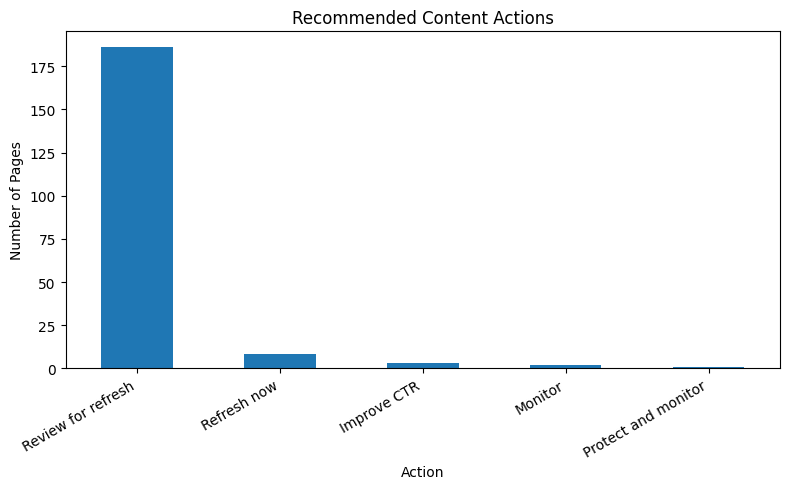

Figure saved to:
/content/Flyrank-ML-internship/work/figures/w07_action_distribution.png


In [22]:
action_counts = (
    ranked_queue["recommended_action"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

action_counts.plot(kind="bar")

plt.title("Recommended Content Actions")
plt.xlabel("Action")
plt.ylabel("Number of Pages")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

figure_path = FIGURE_DIR / "w07_action_distribution.png"

plt.savefig(figure_path, dpi=200)

plt.show()

print("Figure saved to:")
print(figure_path)

In [23]:
export_columns = [
    "priority_rank",
    "content_id",
    "recommended_action",
    "reason_codes",
    "priority_score",
    "expected_value",
    "estimated_effort",
    "cost_value_label",
    "confidence",
    "trend_direction",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "days_since_last_update"
]

queue_export = ranked_queue[export_columns]

queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"

queue_export.to_csv(queue_path, index=False)

print("Queue exported successfully!")

print(queue_path)

queue_export.head()

Queue exported successfully!
/content/Flyrank-ML-internship/work/outputs/w07_ranked_action_queue.csv


,priority_rank,content_id,recommended_action,reason_codes,priority_score,expected_value,estimated_effort,cost_value_label,confidence,trend_direction,impressions_90d,clicks_90d,ctr,avg_position,days_since_last_update
0,1,content_ac1d924c6a70,Refresh now,HIGH_IMPRESSIONS|STALE_CONTENT|DECLINING_TREND,0.7839,High,Medium,Strategic priority,high,down,21853,28,0.13,31.7,106
1,2,content_c9eeaab4031e,Refresh now,HIGH_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLINI...,0.7685,High,Medium,Strategic priority,high,down,34100,7,0.02,6.2,104
2,3,content_2143794a59ca,Refresh now,HIGH_IMPRESSIONS|LOW_CTR|STALE_CONTENT|DECLINI...,0.7444,Medium,Medium,Review when capacity allows,medium,down,26413,8,0.03,5.5,104
3,4,content_1bfaa38ff26c,Refresh now,HIGH_IMPRESSIONS|STRONG_CTR|STALE_CONTENT|DECL...,0.7421,Medium,Medium,Review when capacity allows,high,down,25715,60,0.23,22.2,194
4,5,content_972b37f0c86d,Refresh now,HIGH_IMPRESSIONS|STALE_CONTENT|DECLINING_TREND,0.7227,Medium,Medium,Review when capacity allows,high,down,27437,19,0.07,7.2,104


In [24]:
import json

summary = {
    "total_pages": int(len(ranked_queue)),
    "action_distribution": ranked_queue[
        "recommended_action"
    ].value_counts().to_dict(),
    "median_priority_score": float(
        ranked_queue["priority_score"].median()
    ),
    "high_priority_pages": int(
        (ranked_queue["expected_value"]=="High").sum()
    ),
    "human_review_required": True,
    "automatic_publishing_allowed": False
}

summary_path = OUTPUT_DIR / "w07_action_playbook_metrics.json"

with open(summary_path,"w") as f:
    json.dump(summary,f,indent=4)

print(summary)

print("\nSaved to:")
print(summary_path)

{'total_pages': 200, 'action_distribution': {'Review for refresh': 186, 'Refresh now': 8, 'Improve CTR': 3, 'Monitor': 2, 'Protect and monitor': 1}, 'median_priority_score': 0.54785, 'high_priority_pages': 5, 'human_review_required': True, 'automatic_publishing_allowed': False}

Saved to:
/content/Flyrank-ML-internship/work/outputs/w07_action_playbook_metrics.json


In [25]:
import os

print("Files in work/outputs:\n")

for f in os.listdir(OUTPUT_DIR):
    print(f)

Files in work/outputs:

w07_ranked_action_queue.csv
w07_action_playbook_metrics.json


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.